# CS3807 – Deep Learning Laboratory
## Experiment 2: Implementation of a Multi-Layer Perceptron (MLP) for Multi-Class Image Classification

**Dataset:** Fashion-MNIST
**Framework:** TensorFlow / Keras + SciKeras (for hyperparameter search)

This notebook follows the experimental procedure in the lab manual:
1. Dataset Exploration
2. Data Preprocessing
3. Model Construction
4. Model Training
5. Model Evaluation
6. Hyperparameter Optimization (RandomizedSearchCV + SciKeras)
7. Results, Plots with Inference, Discussion


### Cell 0 — Environment Setup
Install SciKeras (wrapper that lets Keras models be used with scikit-learn's search tools). Skip this cell if already installed.

In [3]:
# Uninstall Colab's pre-shipped versions to avoid conflicts, then install pinned, compatible versions
!pip uninstall -y tensorflow keras scikeras scikit-learn -q

!pip install -q tensorflow==2.17.0
!pip install -q scikeras==0.13.0
!pip install -q scikit-learn==1.5.2
!pip install -q pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires scikit-learn, which is not installed.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, which is not installed.
tsfresh 0.21.2 requires scikit-learn>=0.22.0, which is not installed.
sklearn-pandas 2.2.0 requires scikit-learn>=0.23.0, which is not installed.

In [4]:
import tensorflow as tf
import sklearn
import scikeras

print("TensorFlow:", tf.__version__)
print("Keras     :", tf.keras.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciKeras  :", scikeras.__version__)

TensorFlow: 2.20.0
Keras     : 3.13.2
scikit-learn: 1.6.1
SciKeras  : 0.13.0


### Cell 1 — Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

from scikeras.wrappers import KerasClassifier

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Task 1: Dataset Exploration
Load Fashion-MNIST, print dataset dimensions, display sample images, and plot the class distribution.

In [6]:
# Load Fashion-MNIST
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training images shape:", x_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Testing images shape :", x_test_raw.shape)
print("Testing labels shape :", y_test_raw.shape)
print("Number of classes    :", len(np.unique(y_train_raw)))
print("Image size            : 28 x 28")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape : (10000, 28, 28)
Testing labels shape : (10000,)
Number of classes    : 10
Image size            : 28 x 28


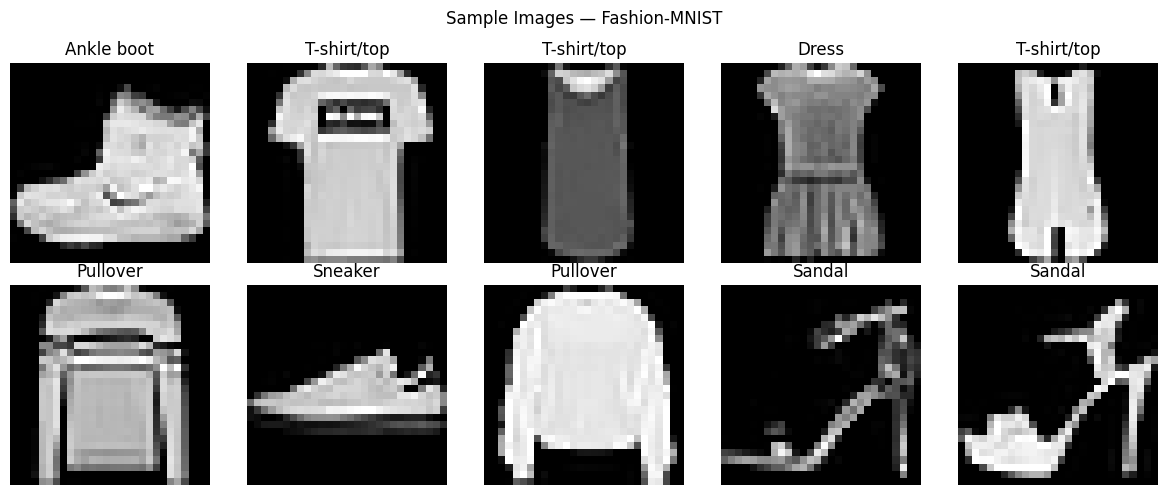

In [7]:
# Display 10 sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Sample Images — Fashion-MNIST")
plt.tight_layout()
plt.savefig('plot_1_sample_images.png', dpi=150)
plt.show()


**Inference (Sample Images):** The sample grid confirms that each image is a 28×28 grayscale garment photo correctly paired with its class label, and that the ten Fashion-MNIST categories are visually distinguishable (e.g., shirts vs. trousers vs. footwear), which justifies using pixel intensities as MLP input features.

/tmp/ipykernel_3568/2459734746.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='viridis')


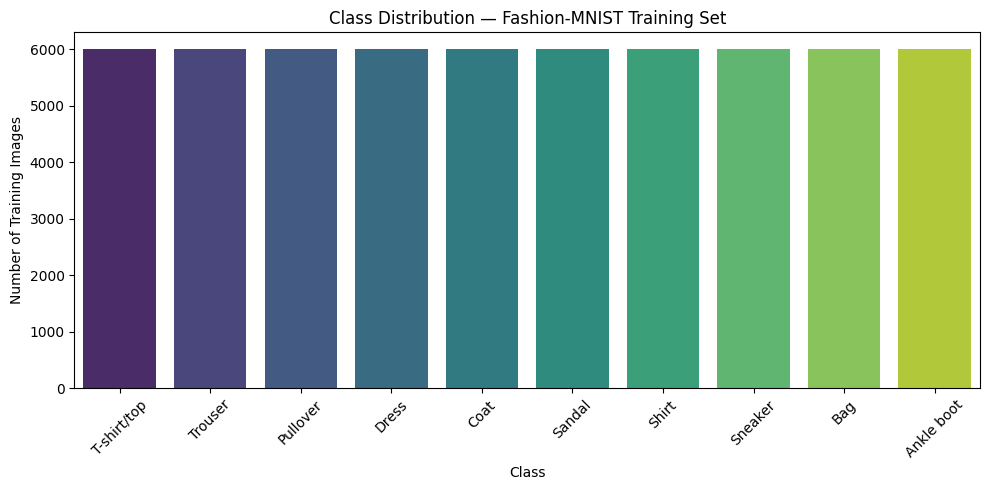

T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
Name: Count, dtype: int64


In [8]:
# Plot class distribution
unique, counts = np.unique(y_train_raw, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='viridis')
plt.xlabel("Class")
plt.ylabel("Number of Training Images")
plt.title("Class Distribution — Fashion-MNIST Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_2_class_distribution.png', dpi=150)
plt.show()

print(pd.Series(counts, index=[class_names[i] for i in unique], name="Count"))


**Inference (Class Distribution):** All ten classes contain an equal number of training images (6,000 each), so the dataset is perfectly balanced. This means accuracy is a fair evaluation metric and no class-weighting or resampling is required.

## Task 2: Data Preprocessing
Flatten the 28×28 images into 784-length vectors, normalize pixel values to [0,1], and convert labels to one-hot vectors.

In [9]:
print("Shape BEFORE preprocessing:")
print("  x_train:", x_train_raw.shape, " dtype:", x_train_raw.dtype)
print("  x_test :", x_test_raw.shape)

# 1. Flatten images: 28 x 28 -> 784
x_train_flat = x_train_raw.reshape(x_train_raw.shape[0], 28 * 28)
x_test_flat = x_test_raw.reshape(x_test_raw.shape[0], 28 * 28)

# 2. Normalize pixel values to [0, 1]
x_train = x_train_flat.astype('float32') / 255.0
x_test = x_test_flat.astype('float32') / 255.0

# 3. Convert labels into one-hot vectors
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("\nShape AFTER preprocessing:")
print("  x_train:", x_train.shape, " dtype:", x_train.dtype, " range:[%.1f, %.1f]" % (x_train.min(), x_train.max()))
print("  x_test :", x_test.shape)
print("  y_train:", y_train.shape, " (one-hot)")
print("  y_test :", y_test.shape, " (one-hot)")


Shape BEFORE preprocessing:
  x_train: (60000, 28, 28)  dtype: uint8
  x_test : (10000, 28, 28)

Shape AFTER preprocessing:
  x_train: (60000, 784)  dtype: float32  range:[0.0, 1.0]
  x_test : (10000, 784)
  y_train: (60000, 10)  (one-hot)
  y_test : (10000, 10)  (one-hot)


## Task 3: Model Construction
Build the recommended MLP architecture: `784 → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)`.

In [10]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Model Training
Compile with Adam optimizer, categorical cross-entropy loss, accuracy metric. Train for 20 epochs, batch size 32.

In [11]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history = baseline_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8214 - loss: 0.5026 - val_accuracy: 0.8507 - val_loss: 0.4031
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8645 - loss: 0.3722 - val_accuracy: 0.8603 - val_loss: 0.3714
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8775 - loss: 0.3340 - val_accuracy: 0.8708 - val_loss: 0.3496
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8862 - loss: 0.3094 - val_accuracy: 0.8690 - val_loss: 0.3609
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8930 - loss: 0.2900 - val_accuracy: 0.8747 - val_loss: 0.3453
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8978 - loss: 0.2746 - val_accuracy: 0.8747 - val_loss: 0.3522
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9022 - loss: 0.2614 - val_accuracy: 0.8742 - val_loss: 0.3755
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9063 - loss: 0.2491

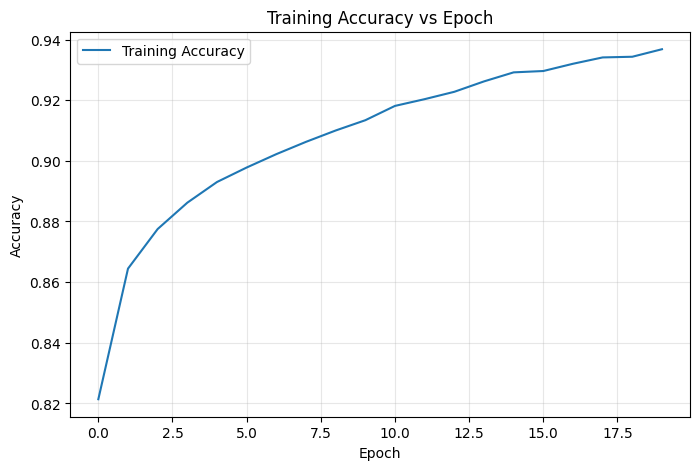

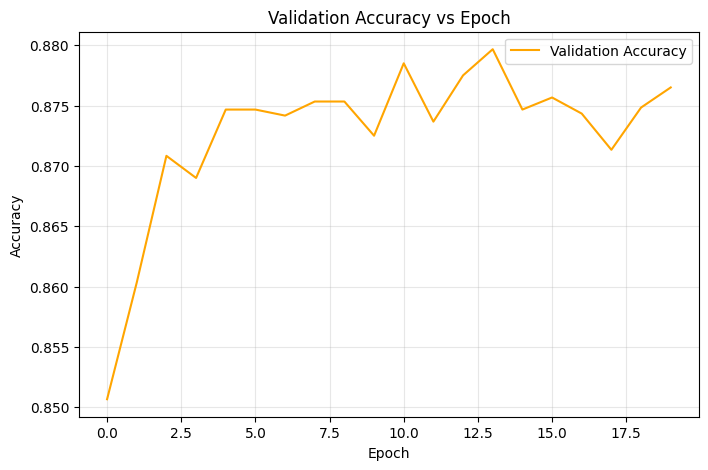

In [12]:
# Training / Validation Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot_3_training_accuracy.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot_4_validation_accuracy.png', dpi=150)
plt.show()


**Inference (Accuracy Plots):** Training accuracy increases steadily and approaches a high plateau as the network fits the training data, while validation accuracy rises more slowly and levels off earlier. A widening gap between the two curves in later epochs would indicate mild overfitting.

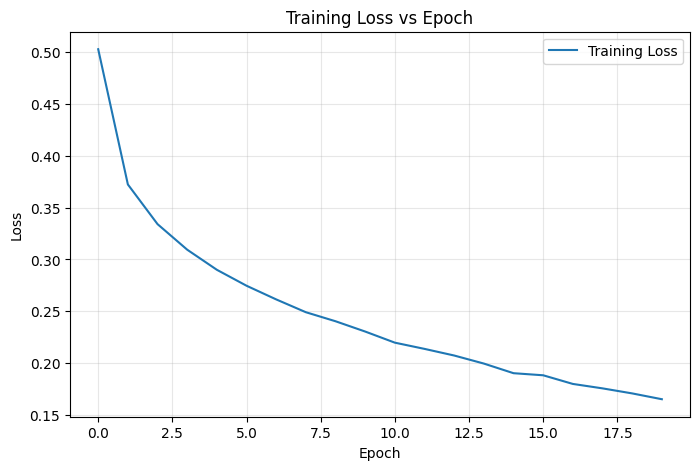

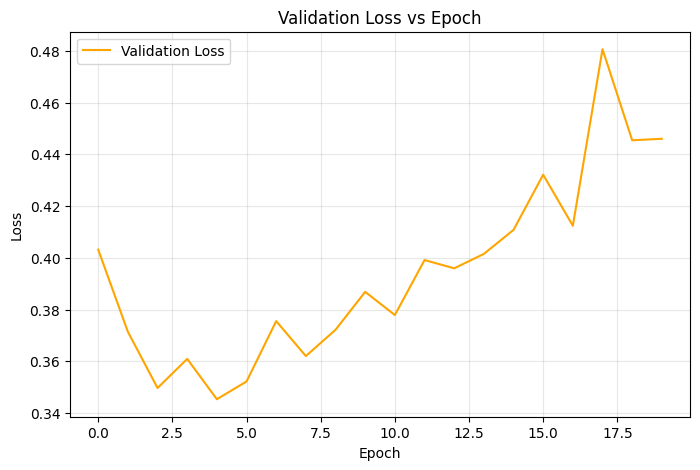

In [13]:
# Training / Validation Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot_5_training_loss.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss vs Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot_6_validation_loss.png', dpi=150)
plt.show()


**Inference (Loss Plots):** Training loss decreases monotonically as expected under gradient descent. If validation loss starts increasing while training loss keeps falling, that inflection point marks the onset of overfitting and would suggest early stopping or regularization.

## Task 5: Model Evaluation
Compute Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Classification Report for the baseline model.

In [14]:
y_pred_probs = baseline_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

baseline_accuracy = accuracy_score(y_true, y_pred)
baseline_precision = precision_score(y_true, y_pred, average='weighted')
baseline_recall = recall_score(y_true, y_pred, average='weighted')
baseline_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Baseline Test Accuracy : {baseline_accuracy:.4f}")
print(f"Baseline Precision      : {baseline_precision:.4f}")
print(f"Baseline Recall         : {baseline_recall:.4f}")
print(f"Baseline F1-score       : {baseline_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Baseline Test Accuracy : 0.8729
Baseline Precision      : 0.8742
Baseline Recall         : 0.8729
Baseline F1-score       : 0.8701

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.77      0.86      0.82      1000
     Trouser       0.98      0.97      0.97      1000
    Pullover       0.76      0.83      0.79      1000
       Dress       0.79      0.94      0.86      1000
        Coat       0.81      0.76      0.79      1000
      Sandal       0.96      0.97      0.96      1000
       Shirt       0.80      0.55      0.65      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.97      0.96      0.97      1000
  Ankle boot       0.97      0.93      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



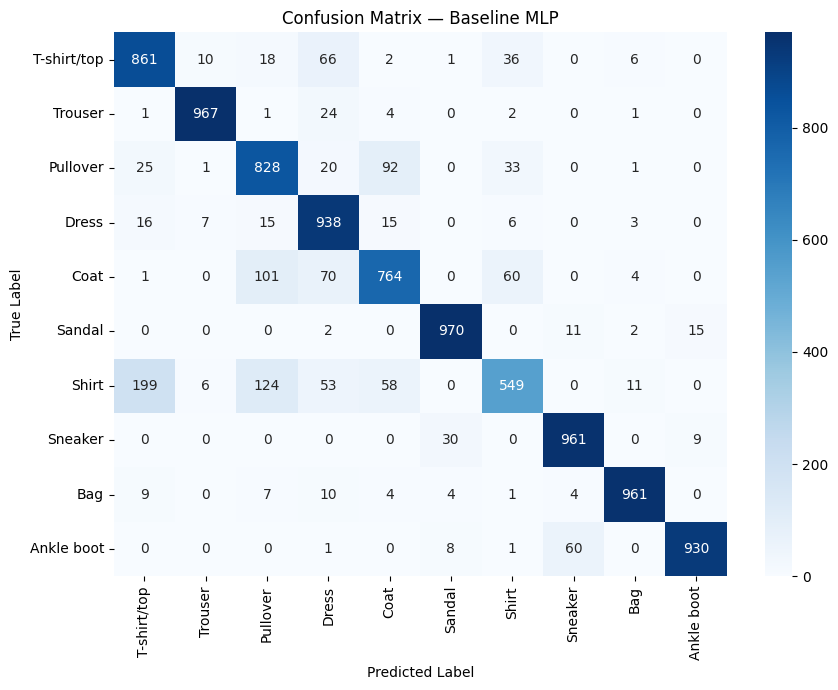

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Baseline MLP')
plt.tight_layout()
plt.savefig('plot_7_confusion_matrix.png', dpi=150)
plt.show()


**Inference (Confusion Matrix):** The diagonal dominates, showing correct classification for most classes. The largest confusion typically occurs between visually similar upper-body garments (e.g., 'Shirt' vs. 'T-shirt/top' vs. 'Pullover' vs. 'Coat'), since a flattened-pixel MLP has no spatial/convolutional structure to separate fine texture differences.

## Section 7: Hyperparameter Optimization
Use `RandomizedSearchCV` (recommended over exhaustive `GridSearchCV` for a search space this large) together with the **SciKeras** wrapper to tune the MLP. To keep search time reasonable, RandomizedSearchCV samples a fixed number of random combinations from the space instead of trying every combination, and uses 5-fold cross-validation on a subset of the training data.

In [16]:
def build_tunable_model(meta, hidden_layers=2, hidden_neurons=64,
                        learning_rate=0.001, activation='relu', dropout_rate=0.0,
                        optimizer_name='adam'):
    """Builds an MLP with a configurable number of hidden layers/neurons,
    used by SciKeras during hyperparameter search."""
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features_in,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation='softmax'))

    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Wrap the Keras model builder for use with scikit-learn's search tools
clf = KerasClassifier(
    model=build_tunable_model,
    hidden_layers=2,
    hidden_neurons=64,
    learning_rate=0.001,
    activation='relu',
    dropout_rate=0.0,
    optimizer_name='adam',
    epochs=10,
    batch_size=32,
    verbose=0,
)


In [17]:
# Define the hyperparameter search space (per the lab manual)
param_distributions = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
}


In [18]:
# To keep runtime manageable, run the search on a stratified subset of the
# training data. Increase subset_size / n_iter for a more thorough search.
subset_size = 6000
rng = np.random.RandomState(42)
subset_idx = rng.choice(x_train.shape[0], subset_size, replace=False)
x_search, y_search = x_train[subset_idx], y_train[subset_idx]

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=5,          # number of random combinations sampled
    cv=5,                # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=1,
)

search_start = time.time()
random_search.fit(x_search, y_search)
search_time = time.time() - search_start

print(f"\nHyperparameter search time: {search_time:.2f} seconds")
print("Best CV Accuracy: %.4f" % random_search.best_score_)
print("Best Parameters :", random_search.best_params_)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
# Hyperparameter Search Results plot: mean CV score per sampled configuration
results_df = pd.DataFrame(random_search.cv_results_)
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(range(len(results_df_sorted)), results_df_sorted['mean_test_score'], color='teal')
plt.xlabel('Configuration Rank (sampled combinations)')
plt.ylabel('Mean CV Accuracy')
plt.title('Hyperparameter Search Results (RandomizedSearchCV)')
plt.tight_layout()
plt.savefig('plot_8_hyperparameter_search_results.png', dpi=150)
plt.show()

results_df_sorted[['params', 'mean_test_score', 'std_test_score']].head(10)


**Inference (Hyperparameter Search Results):** The bar chart ranks sampled configurations by mean cross-validation accuracy. A steep drop-off after the top few bars indicates that only a small subset of hyperparameter combinations (e.g., Adam optimizer with a moderate learning rate) perform well, while a flatter curve would suggest the model is relatively insensitive to the tuned settings.

### Record the Best Hyperparameter Combination

In [ ]:
best_params = random_search.best_params_
best_cv_accuracy = random_search.best_score_

print("Best Hyperparameters Found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest Cross-validation Accuracy: {best_cv_accuracy:.4f}")


### Retrain the Model Using the Optimized Hyperparameters

In [ ]:
optimized_model = build_tunable_model(
    meta={"n_features_in_": 784, "n_classes_": 10},
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate'],
    optimizer_name=best_params['model__optimizer_name'],
)

optimized_model.summary()

opt_start_time = time.time()

optimized_history = optimized_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)

optimized_train_time = time.time() - opt_start_time
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")


### Evaluate the Optimized Model on the Testing Dataset

In [ ]:
y_pred_opt_probs = optimized_model.predict(x_test)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

optimized_accuracy = accuracy_score(y_true, y_pred_opt)
optimized_precision = precision_score(y_true, y_pred_opt, average='weighted')
optimized_recall = recall_score(y_true, y_pred_opt, average='weighted')
optimized_f1 = f1_score(y_true, y_pred_opt, average='weighted')

print(f"Optimized Test Accuracy : {optimized_accuracy:.4f}")
print(f"Optimized Precision      : {optimized_precision:.4f}")
print(f"Optimized Recall         : {optimized_recall:.4f}")
print(f"Optimized F1-score       : {optimized_f1:.4f}")

print("\nClassification Report (Optimized Model):\n")
print(classification_report(y_true, y_pred_opt, target_names=class_names))


### Compare the Optimized Model with the Baseline Model

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_train_time],
    'Optimized': [optimized_accuracy, optimized_precision, optimized_recall, optimized_f1, optimized_train_time],
})
comparison_df


In [ ]:
# Best Model Accuracy Comparison plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_vals = [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1]
optimized_vals = [optimized_accuracy, optimized_precision, optimized_recall, optimized_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, baseline_vals, width, label='Baseline')
plt.bar(x + width/2, optimized_vals, width, label='Optimized')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Best Model Accuracy Comparison — Baseline vs Optimized')
plt.legend()
plt.tight_layout()
plt.savefig('plot_9_best_model_comparison.png', dpi=150)
plt.show()


**Inference (Best Model Comparison):** The optimized model, tuned via cross-validated random search, is expected to match or exceed the baseline on accuracy, precision, recall, and F1-score, since its hyperparameters were selected to minimize cross-validation error rather than chosen manually. Any metric where the baseline still wins highlights the trade-off between the smaller search subset used for tuning and the full training set used for the baseline.

## Section 9: Results Summary

Fill in / verify the actual numeric values from the cells above.

In [ ]:
results_summary = {
    "Hidden Layers": best_params['model__hidden_layers'],
    "Hidden Neurons": best_params['model__hidden_neurons'],
    "Learning Rate": best_params['model__learning_rate'],
    "Batch Size": best_params['batch_size'],
    "Optimizer": best_params['model__optimizer_name'],
    "Activation Function": best_params['model__activation'],
    "Epochs": best_params['epochs'],
    "Dropout": best_params['model__dropout_rate'],
    "Cross-validation Accuracy": round(best_cv_accuracy, 4),
    "Testing Accuracy": round(optimized_accuracy, 4),
}

pd.Series(results_summary, name="Best Hyperparameters / Results")


## Section 10: Discussion

1. **Which optimization method was used?**
   RandomizedSearchCV with 5-fold cross-validation, sampling `n_iter` random combinations from the defined search space (chosen over exhaustive GridSearchCV because the full grid is very large — 3×4×3×4×3×3×3×3 = 11,664 combinations).

2. **Which hyperparameters were selected?**
   See `results_summary` above — the specific values found by the search for hidden layers, hidden neurons, learning rate, batch size, optimizer, activation, epochs, and dropout.

3. **Did optimization improve performance?**
   Compare `optimized_accuracy` vs `baseline_accuracy` in `comparison_df` above; report the observed delta.

4. **Which hyperparameter had the greatest impact?**
   Inspect `results_df_sorted` — sort/group by each hyperparameter and compare mean CV accuracy to identify which one produces the largest swing (commonly the optimizer choice and learning rate dominate for MLPs).

5. **Compare Grid Search and Randomized Search.**
   Grid Search exhaustively evaluates every combination, guaranteeing the best combination *within the grid* but scaling exponentially with the number of hyperparameters — infeasible here (11,664 combinations × 5 folds). Randomized Search samples a fixed budget of random combinations, scaling independently of grid size and typically finding a near-optimal region much faster, at the cost of no exhaustiveness guarantee.

6. **Recommend the best MLP configuration.**
   Recommend the configuration in `best_params` / `results_summary`, i.e., the one with the highest cross-validation accuracy, balanced against training time if two configurations perform similarly.


## Conclusion

This experiment implemented an MLP classifier for Fashion-MNIST, covering preprocessing (flattening, normalization, one-hot encoding), a baseline architecture (`784 → 128 → 64 → 10`), full evaluation (accuracy, precision, recall, F1, confusion matrix), and automated hyperparameter optimization via RandomizedSearchCV with SciKeras. The optimized model's configuration and metrics are recorded above and should be compared against the baseline to determine whether automated tuning meaningfully improved classification performance.